In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# Number of ICD-10 codes per claim:

In [2]:
def read_and_count(data):
    df = pd.read_csv(data, header=None)
    sum_of_claims = df[1].values.sum()  # Sum of the second column
    return sum_of_claims

In [3]:
directory_path = '/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA'

search_pattern = os.path.join(directory_path, 'diag*.csv')

# Use glob.glob to find all files matching the pattern
matching_files = glob.glob(search_pattern)

sums_dict = {}

print("Found CSV files:")
for file in matching_files:
    sums_dict[os.path.basename(file)] = read_and_count(file)



Found CSV files:


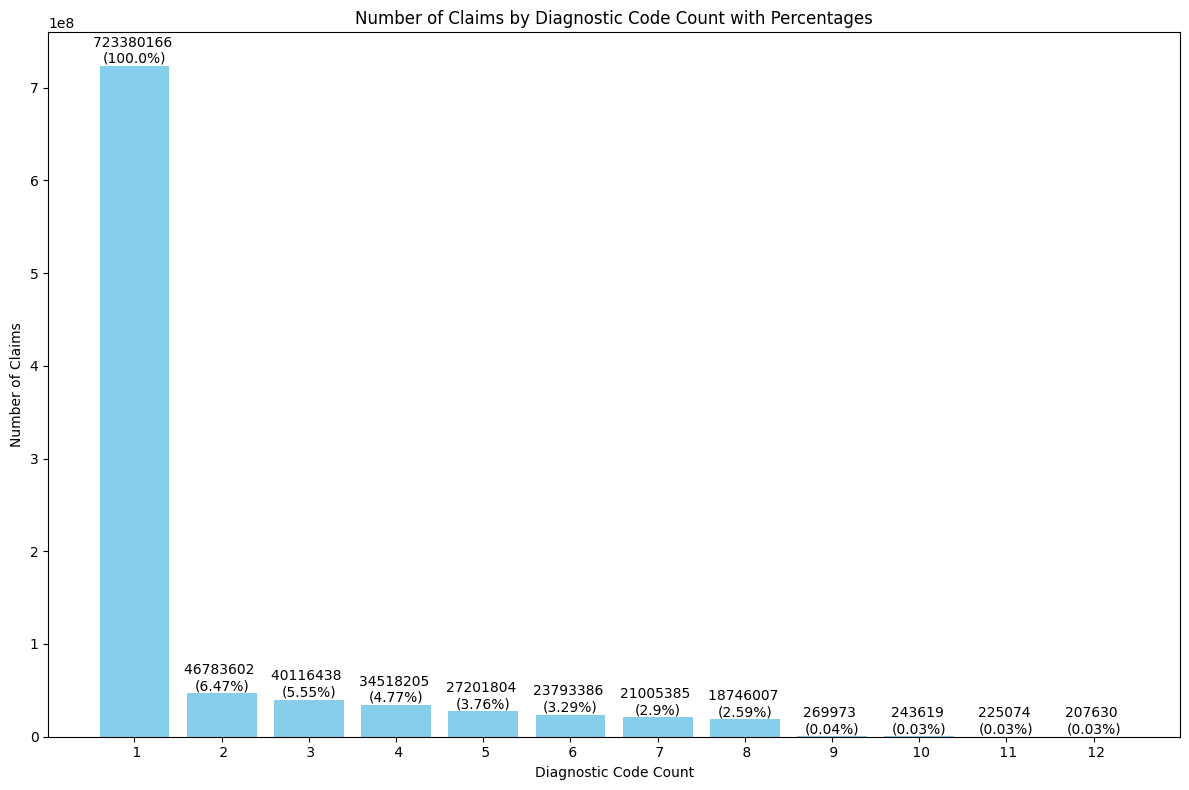

In [4]:

# Find the maximum sum of claims to calculate percentages
max_sum = max(sums_dict.values())

# Sort the dictionary by its values (sum of claims) in descending order
sorted_sums_dict = dict(sorted(sums_dict.items(), key=lambda item: item[1], reverse=True))

# Calculate the percentage of each sum relative to the maximum
percentages_dict = {key: (value / max_sum) * 100 for key, value in sorted_sums_dict.items()}

# Generate generic labels for the x-axis
generic_labels = [f" {i+1}" for i in range(len(sorted_sums_dict))]

# Now, visualize the sorted data using matplotlib
plt.figure(figsize=(12, 8))
bars = plt.bar(generic_labels, sorted_sums_dict.values(), color='skyblue')

# Add text annotations on top of each bar for the number of claims and percentage
for bar, sum_of_claims in zip(bars, sorted_sums_dict.values()):
    percentage = (sum_of_claims / max_sum) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, sum_of_claims, 
             f"{round(sum_of_claims, 2)} \n({round(percentage, 2)}%)", 
             ha='center', va='bottom')

plt.xlabel('Diagnostic Code Count')
plt.ylabel('Number of Claims')
plt.title('Number of Claims by Diagnostic Code Count with Percentages')
plt.tight_layout()
plt.show()

Those numbers are comming from summing up the number of accurances of each ICD-10 code in diag_x column. For example, the first one (723 million) is the sum of numbers of occurances of all ICD-10 codes in diag_1.

# Removing Duplicate ICD-9 and ICD-10 to avoid confusion:

* set the cutoff to 4k or 5k
* 

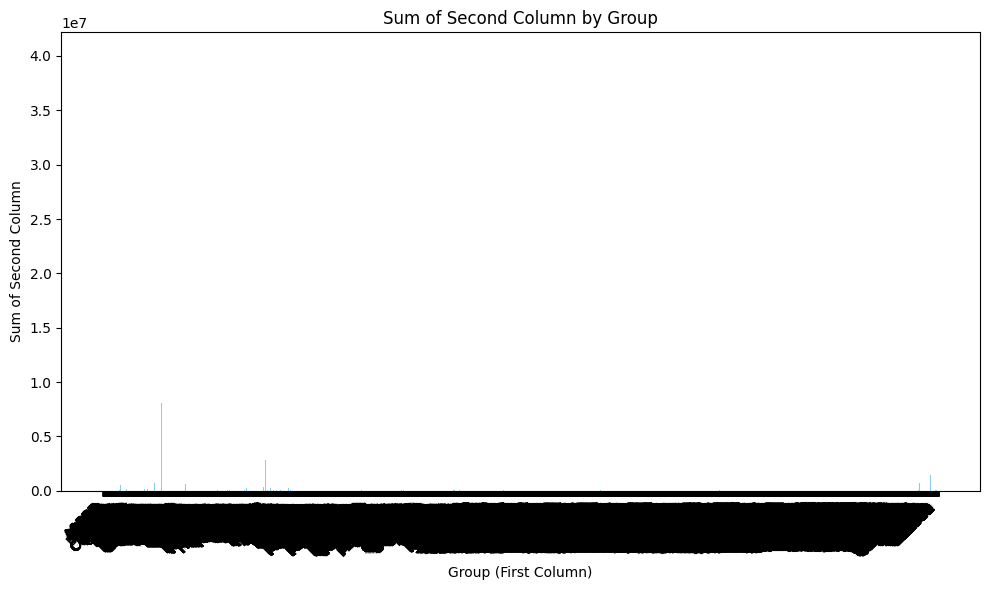

In [5]:

directory_path = '/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA'
search_pattern = os.path.join(directory_path, 'diag*.csv')

# Use glob.glob to find all files matching the pattern
matching_files = glob.glob(search_pattern)

# List to hold data from all files
dataframes_list = []

# Read each file and append to the list
for file in matching_files:
    df = pd.read_csv(file, header=None)
    dataframes_list.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dataframes_list, ignore_index=True)

# Group by the first column and sum the second column for each group
aggregated_df = combined_df.groupby(0).agg({1: 'sum'}).reset_index()

# Now, you can visualize the aggregated data (sum of the second column)
plt.figure(figsize=(10, 6))
plt.bar(aggregated_df[0].astype(str), aggregated_df[1], color='skyblue')
plt.xlabel('Group (First Column)')
plt.ylabel('Sum of Second Column')
plt.title('Sum of Second Column by Group')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [2]:
df_all = pd.read_csv("/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA/Diags_all.csv", header = None)
df_all

,0,1,2
0,40165321,V202,UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLIS...
1,31892993,V700,DRIVER OF BUS INJURED IN COLLISION WITH PEDEST...
2,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
3,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
4,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...
...,...,...,...
55686,1,B9731,LENTIVIRUS AS THE CAUSE OF DISEASES CLASSIFIED...
55687,1,E093512,DRUG OR CHEMICAL INDUCED DIABETES MELLITUS WIT...
55688,1,E093519,DRUG OR CHEMICAL INDUCED DIABETES MELLITUS WIT...
55689,1,F18259,INHALANT DEPENDENCE WITH INHALANT-INDUCED PSYC...


In [3]:
sorted_aggregated_df = aggregated_df.sort_values(by=1, ascending=False, )
sorted_aggregated_df.reset_index(drop=True, inplace=True)

sorted_aggregated_df

NameError: name 'aggregated_df' is not defined

The numbers between df_all and the one aggregated from the seperate files match, so I will continuw with df_all instead because it already has icd_desc.

In [4]:
df_all

,0,1,2
0,40165321,V202,UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLIS...
1,31892993,V700,DRIVER OF BUS INJURED IN COLLISION WITH PEDEST...
2,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
3,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
4,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...
...,...,...,...
55686,1,B9731,LENTIVIRUS AS THE CAUSE OF DISEASES CLASSIFIED...
55687,1,E093512,DRUG OR CHEMICAL INDUCED DIABETES MELLITUS WIT...
55688,1,E093519,DRUG OR CHEMICAL INDUCED DIABETES MELLITUS WIT...
55689,1,F18259,INHALANT DEPENDENCE WITH INHALANT-INDUCED PSYC...


In [9]:
# removing the ICD-10s bellow 40k:

#df_all_filtered = df_all[df_all[0] >= 40000]


#df_all_filtered.reset_index(drop=True, inplace=True)
#df_all_filtered

,0,1,2
0,40165321,V202,UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLIS...
1,31892993,V700,DRIVER OF BUS INJURED IN COLLISION WITH PEDEST...
2,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
3,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
4,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...
...,...,...,...
2325,40165,Z3A34,34 WEEKS GESTATION OF PREGNANCY
2326,40127,C252,MALIGNANT NEOPLASM OF TAIL OF PANCREAS
2327,40107,G9009,OTHER IDIOPATHIC PERIPHERAL AUTONOMIC NEUROPATHY
2328,40080,K5903,DRUG INDUCED CONSTIPATION


In [16]:
# sampling 5 for generation testing:


#sampled_rows = df_all_filtered.sample(5)

# Return values in the second column of the sampled rows in a list
#sample_5_icds = sampled_rows.iloc[:, 1].tolist()
#sample_5_icds

#sampled_rows

,0,1,2
1291,94000,B009,"HERPESVIRAL INFECTION, UNSPECIFIED"
334,472643,H903,"SENSORINEURAL HEARING LOSS, BILATERAL"
440,341632,B182,CHRONIC VIRAL HEPATITIS C
145,892745,F332,"MAJOR DEPRESSIVE DISORDER, RECURRENT SEVERE WI..."
221,630768,G894,CHRONIC PAIN SYNDROME


In [21]:
#all_text_third_column = sampled_rows.iloc[:, 2].to_list()
#all_text_third_column

['HERPESVIRAL INFECTION, UNSPECIFIED',
 'SENSORINEURAL HEARING LOSS, BILATERAL',
 'CHRONIC VIRAL HEPATITIS C',
 'MAJOR DEPRESSIVE DISORDER, RECURRENT SEVERE WITHOUT PSYCHOTIC FEATURES',
 'CHRONIC PAIN SYNDROME']

## finding overlap between ICD9 and ICD10:

In [5]:
overlap_df = pd.read_csv("/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA/ICD9vs10desc.csv", sep="|")
overlap_df.head(10)

,dx_cd,diagnosis_desc,diag_vers_typ_id
0,E000,EXTERNAL CAUSE STATUS,1
1,E000,"CONGENITAL IODINE-DEFICIENCY SYNDROME, NEUROLO...",2
2,E001,ACTIVITIES INVOLVING WALKING AND RUNNING,1
3,E001,"CONGENITAL IODINE-DEFICIENCY SYNDROME, MYXEDEM...",2
4,E002,ACTIVITIES INVOLVING WATER AND WATER CRAFT,1
5,E002,"CONGENITAL IODINE-DEFICIENCY SYNDROME, MIXED TYPE",2
6,E009,ACTIVITY INVOLVING OTHER CARDIORESPIRATORY EXE...,1
7,E009,"CONGENITAL IODINE-DEFICIENCY SYNDROME, UNSPECI...",2
8,E010,ACTIVITY INVOLVING OTHER MUSCLE STRENGTHENING ...,1
9,E010,IODINE-DEFICIENCY RELATED DIFFUSE (ENDEMIC) GO...,2


In [6]:
# reshaping

reshaped_overlap_df = overlap_df.pivot(index='dx_cd', columns='diag_vers_typ_id', values='diagnosis_desc')

# Rename columns for clarity
reshaped_overlap_df.columns = ['ICD9', 'ICD10']  # Assuming '1' corresponds to 'ICD9' and '2' to 'ICD10'

reshaped_overlap_df

,ICD9,ICD10
dx_cd,,
E000,EXTERNAL CAUSE STATUS,"CONGENITAL IODINE-DEFICIENCY SYNDROME, NEUROLO..."
E001,ACTIVITIES INVOLVING WALKING AND RUNNING,"CONGENITAL IODINE-DEFICIENCY SYNDROME, MYXEDEM..."
E002,ACTIVITIES INVOLVING WATER AND WATER CRAFT,"CONGENITAL IODINE-DEFICIENCY SYNDROME, MIXED TYPE"
E009,ACTIVITY INVOLVING OTHER CARDIORESPIRATORY EXE...,"CONGENITAL IODINE-DEFICIENCY SYNDROME, UNSPECI..."
E010,ACTIVITY INVOLVING OTHER MUSCLE STRENGTHENING ...,IODINE-DEFICIENCY RELATED DIFFUSE (ENDEMIC) GO...
...,...,...
V9119,"TRIPLET GESTATION, UNABLE TO DETERMINE NUMBER ...",CRUSHED BETWEEN UNSPECIFIED WATERCRAFT AND OTH...
V9120,"QUADRUPLET GESTATION, UNSPECIFIED NUMBER OF PL...",FALL DUE TO COLLISION BETWEEN MERCHANT SHIP AN...
V9121,"QUADRUPLET GESTATION, WITH TWO OR MORE MONOCHO...",FALL DUE TO COLLISION BETWEEN PASSENGER SHIP A...


In [28]:
reshaped_overlap_df.to_csv("/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA/ICD9vs10desc_reshaped.csv", sep="|")

## Removing the duplicates from the distribution data:

We have 733 duplicate codes. We remove all of them to avoid confusion. 

In [30]:
# the whole distribution data:
#df_all

# the overlap data:
#reshaped_overlap_df


In [7]:
# Step 1: Extract values from the first column of reshaped_overlap_df
values_to_filter = reshaped_overlap_df.index.unique()

duplicates= df_all[df_all.iloc[:, 1].isin(values_to_filter)]  

duplicates


,0,1,2
0,40165321,V202,UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLIS...
1,31892993,V700,DRIVER OF BUS INJURED IN COLLISION WITH PEDEST...
10,7260851,V571,PASSENGER IN PICK-UP TRUCK OR VAN INJURED IN C...
12,6691563,V221,MOTORCYCLE PASSENGER INJURED IN COLLISION WITH...
19,4659637,V762,PERSON ON OUTSIDE OF BUS INJURED IN COLLISION ...
...,...,...,...
52652,1,V9121,FALL DUE TO COLLISION BETWEEN PASSENGER SHIP A...
52667,1,V881,PERSON INJURED IN COLLISION BETWEEN OTHER MOTO...
52687,1,V47,CAR OCCUPANT INJURED IN COLLISION WITH FIXED O...
52720,1,V36,OCCUPANT OF THREE-WHEELED MOTOR VEHICLE INJURE...


In [8]:
# get the ones with no duplicate:

mask = ~df_all.iloc[:, 1].isin(duplicates.iloc[:, 1])
filtered_df = df_all[mask]
filtered_df.reset_index(inplace=True, drop=True)
filtered_df.columns = ["Count", "ICD10", "ICD10_desc"]

In [9]:
# sort:
filtered_df.sort_values(by='Count', ascending=False, inplace=True)


/var/folders/wy/vcwn319j4kj7h2gnjqhn60tm0000gn/T/ipykernel_31746/2929934779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.sort_values(by='Count', ascending=False, inplace=True)


### Analyzing again:

In [10]:
# top 20:
filtered_df.head(20)


,Count,ICD10,ICD10_desc
0,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
1,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
2,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...
3,10470154,Z23,ENCOUNTER FOR IMMUNIZATION
4,9890112,E119,TYPE 2 DIABETES MELLITUS WITHOUT COMPLICATIONS
5,9040289,N186,END STAGE RENAL DISEASE
6,8061616,E785,"HYPERLIPIDEMIA, UNSPECIFIED"
7,7336799,M545,LOW BACK PAIN
8,7073161,G4733,OBSTRUCTIVE SLEEP APNEA (ADULT) (PEDIATRIC)
9,6253356,R69,"ILLNESS, UNSPECIFIED"


In [ ]:
# number of unique ICD10 codes

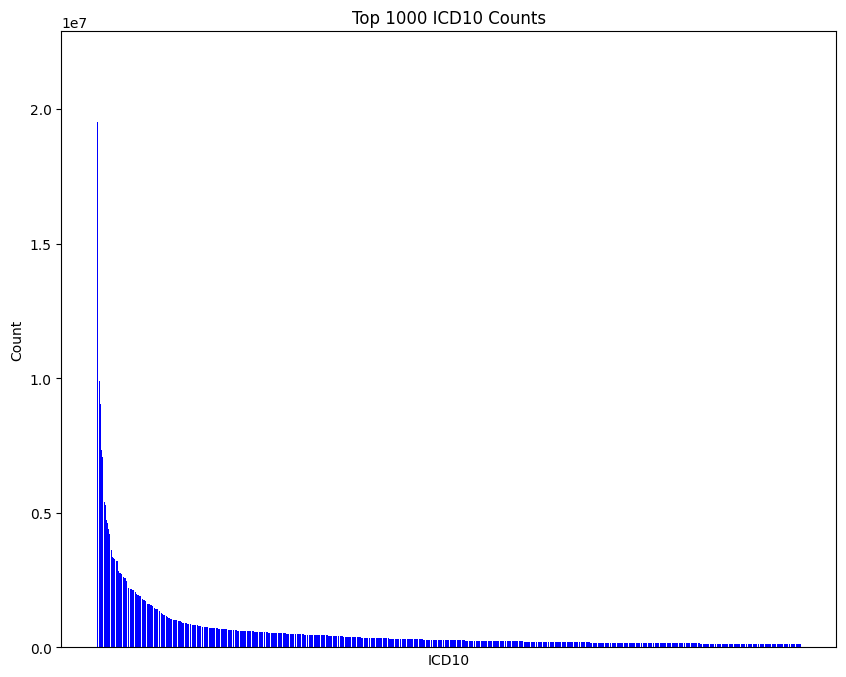

In [53]:
# Select the top 1000 rows
top_1000 = filtered_df.head(1000)

# Step 3: Create a bar chart
plt.figure(figsize=(10, 8))  # Set the figure size as desired
plt.bar(top_1000['ICD10'], top_1000['Count'], color='blue')  # You can customize the color

# Setting labels and title
plt.xlabel('ICD10')
plt.ylabel('Count')
plt.title('Top 1000 ICD10 Counts')

# Rotate x-axis labels if needed and then hide them
plt.xticks(rotation=90)  # Rotate labels for better readability
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Hide x labels

# Show the plot
plt.show()

In [59]:
# summar stats:

# Assuming df_all is already loaded into your environment

# Select the first column; it's good practice to handle potential non-numeric data issues
column_data = pd.to_numeric(filtered_df["Count"], errors='coerce')

# Calculate mean
mean_value = column_data.mean()

# Calculate mode
mode_value = column_data.mode()[0] if not column_data.mode().empty else None  # Handles empty mode

# Calculate variance
variance_value = column_data.var()

# Calculate max
max_value = column_data.max()

# Calculate min
min_value = column_data.min()

# Calculate median
median_value = column_data.median()

# Calculate 25th percentile
percentile_25 = column_data.quantile(0.25)

# Calculate 75th percentile
percentile_75 = column_data.quantile(0.75)

# Printing the results
print(f"Mean: {mean_value}")
print(f"Mode: {mode_value}")
print(f"Variance: {variance_value}")
print(f"Maximum: {max_value}")
print(f"Minimum: {min_value}")
print(f"Median: {median_value}")
print(f"25th Percentile: {percentile_25}")
print(f"75th Percentile: {percentile_75}")

Mean: 14549.765026825498
Mode: 1
Variance: 41387921370.906265
Maximum: 21788529
Minimum: 1
Median: 105.0
25th Percentile: 14.0
75th Percentile: 1056.0


In [11]:
filtered_df

,Count,ICD10,ICD10_desc
0,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
1,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
2,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...
3,10470154,Z23,ENCOUNTER FOR IMMUNIZATION
4,9890112,E119,TYPE 2 DIABETES MELLITUS WITHOUT COMPLICATIONS
...,...,...,...
52931,1,S82865H,NONDISPLACED MAISONNEUVE'S FRACTURE OF LEFT LE...
52932,1,S92031B,DISPLACED AVULSION FRACTURE OF TUBEROSITY OF R...
52933,1,S9047,OTHER SUPERFICIAL BITE OF TOE
52934,1,S82844F,NONDISPLACED BIMALLEOLAR FRACTURE OF RIGHT LOW...


In [15]:

random_indices = np.random.randint(0, 3000, 15)
extracted_values = filtered_df.loc[random_indices, 'ICD10_desc'].tolist()
extracted_values

['LONG TERM (CURRENT) USE OF AROMATASE INHIBITORS',
 'OSTEOPHYTE, VERTEBRAE',
 'PERSONAL HISTORY OF NON-HODGKIN LYMPHOMAS',
 'WEDGE COMPRESSION FRACTURE OF FIRST LUMBAR VERTEBRA, INITIAL ENCOUNTER FOR CLOSED FRACTURE',
 'CUTANEOUS ABSCESS OF GROIN',
 'ACQUIRED KERATOSIS [KERATODERMA] PALMARIS ET PLANTARIS',
 'HEART DISEASE, UNSPECIFIED',
 'SECONDARY AND UNSPECIFIED MALIGNANT NEOPLASM OF LYMPH NODE, UNSPECIFIED',
 'GESTATIONAL DIABETES MELLITUS IN CHILDBIRTH, UNSPECIFIED CONTROL',
 'INCOMPLETE ROTATOR CUFF TEAR OR RUPTURE OF RIGHT SHOULDER, NOT SPECIFIED AS TRAUMATIC',
 'CERVICOBRACHIAL SYNDROME',
 'GANGRENE, NOT ELSEWHERE CLASSIFIED',
 'OTHER ABNORMAL FINDINGS ON DIAGNOSTIC IMAGING OF CENTRAL NERVOUS SYSTEM',
 'DRY EYE SYNDROME OF BILATERAL LACRIMAL GLANDS',
 'DISEASE OF INTESTINE, UNSPECIFIED']

In [12]:
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.width', 1000)  

print(filtered_df.head(20))

       Count   ICD10                                                                             ICD10_desc
0   21788529     I10                                                       ESSENTIAL (PRIMARY) HYPERTENSION
1   19497471   Z0000              ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATION WITHOUT ABNORMAL FINDINGS
2   13272519  Z00129               ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION WITHOUT ABNORMAL FINDINGS
3   10470154     Z23                                                             ENCOUNTER FOR IMMUNIZATION
4    9890112    E119                                         TYPE 2 DIABETES MELLITUS WITHOUT COMPLICATIONS
5    9040289    N186                                                                END STAGE RENAL DISEASE
6    8061616    E785                                                            HYPERLIPIDEMIA, UNSPECIFIED
7    7336799    M545                                                                          LOW BACK PAIN
8    7073161   G4733        